This notebook shows the parametrization of the **omega structure**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/peterropac/Aegolius/blob/main/examples/scalar/2D/omega_structure_2D.ipynb)

# IMPORTS

In [ ]:
#@title Setup
import importlib.util
if importlib.util.find_spec('google.colab') is not None:
    %pip install -q spomso


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spomso.cores.geom import GenericGeometry
from spomso.cores import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_2d import Segment, Arc
from spomso.cores import CombineGeometry

# PARAMETERS

In [2]:
# size of the volume
co_size = 280, 400
# resolution of the volume
co_resolution = 400, 400

show = "FIELD" # BINARY, FIELD
show_midplane = True

# COORDINATE SYSTEM

Point cloud of coordinates is created with the **generate_grid** function, which takes the size of the coordinate system and the number of points in each direction (**co_resolution**).

In [3]:
coor, co_res_new = generate_grid(co_size, co_resolution)

If there is an even number of points along any direction the function will automatically convert it to an odd number, therefore the origin is always included in the point cloud. The point cloud is a numpy.ndarray with a shape of **(D, N)**, where **D** is the number of dimensions and **N** is the number of data points.

# CREATE SDFs

Define the radii, width of the waveguide, the fold-over angle, and the number of repetitions:

In [4]:
R = 100
w = 5
phi = 56
n = 1


Calculate the positions of key points:

In [5]:
phi = np.deg2rad(phi)
period = 4*R*np.cos(phi)
a = R*np.sin(phi)

ixs = np.linspace(0, 2*n + 1, 2*n + 1, endpoint=False)

xs = period*ixs/2
ys = -a*np.cos(2*np.pi*xs/period) + a + R

Offset positions of key points:

In [6]:
x0 = -n*period/2
y0 = -R*(1 + np.sin(phi))
xs = xs + x0
ys = ys + y0
print("structure offset:", xs, ys)

structure offset: [-111.83858069    0.          111.83858069] [-82.90375726  82.90375726 -82.90375726]


Calculate limiting angles for of the arcs:

In [7]:
phi_start = np.ones(ixs.size)
phi_start[1::2] = 0
phi_end = phi + np.pi*(phi_start + 1)
phi_start = np.pi*phi_start - phi
phi_start[0] = 3*np.pi/2
phi_end[-1] = 3*np.pi/2

create the **omega structure**, **inlet**, and **outlet**:

In [8]:
sdfs = []
for i in range(ixs.size):
    s = Arc(R, phi_start[i], phi_end[i])
    s.move((xs[i], ys[i], 0))
    s2 = GenericGeometry(s.propagate, ())
    sdfs.append(s2)

inlet = Segment((-co_size[0]/2, y0, 0), (x0, y0, 0))
outlet = Segment( (x0 + n*period, y0, 0), (co_size[0]/2, y0, 0))

sdfs.append(inlet)
sdfs.append(outlet)
sdfs = tuple(sdfs)

Combine the geometry and give it some thickness:

In [9]:
union = CombineGeometry("UNION")
final = union.combine(*sdfs)
final.rounding(w/2)

<function spomso.cores.modifications.ModifyObject.rounding.<locals>.new_geo_object(co, *params)>

## EVALUATE

Evaluate the SDF of the **olympic rings** to create a signed distance field 2D map. This is done by calling the **create** method and passing in the point cloud of coordinates:

In [10]:
final_pattern = final.create(coor)

# BINARIZATION

Convert the distance field to a binary voxel map, where 1 corresponds to the interior and 0 to the exterior of the geometry.

In [11]:
if show_midplane:
    field = smarter_reshape(final_pattern, co_resolution)
    if show=="BINARY":
        pattern_2d = hard_binarization(field, 0)

# PLOT

Drawing results...
(401, 401)


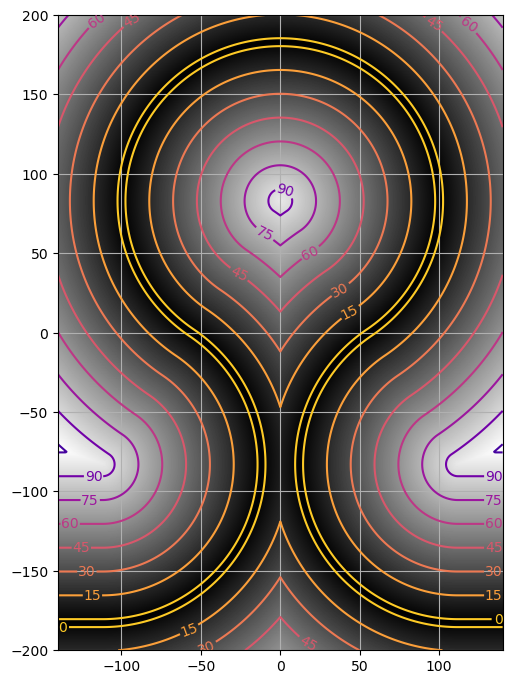

In [12]:
print("Drawing results...")
# Mid-plane cross-section plot
if show_midplane and show=="BINARY":
    fig, ax = plt.subplots(1,1, figsize=(8.25, 8.25))
    ax.imshow(pattern_2d[:, :].T,
              cmap="binary_r",
              extent=(-co_size[0]/2, co_size[0]/2,
                      -co_size[1]/2, co_size[1]/2),
              origin="lower"
              )
    ax.grid()

    fig.tight_layout()
    plt.show()

if show_midplane and show == "FIELD":
    fig, ax = plt.subplots(1, 1, figsize=(8.25, 8.25))
    print(field.shape)
    ax.imshow(field[:, :].T,
              cmap="binary_r",
              extent=(-co_size[0] / 2, co_size[0] / 2,
                      -co_size[1] / 2, co_size[1] / 2),
              origin="lower"
              )
    cs = ax.contour(coor[0].reshape(co_res_new[0], co_res_new[1]),
                    coor[1].reshape(co_res_new[0], co_res_new[1]),
                    field[:, :],
                    cmap="plasma_r")
    ax.clabel(cs, inline=True, fontsize=10)
    ax.grid()